# Лабораторная работа 5

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук — заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm — если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста — не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [ ]:
pre_intro = """1. Для меня переобучение - это когда модель слишком заучила тренировочные данные. Она как будто запомнила ответы вместо того, чтобы понять логику. В итоге на обучении всё выглядит идеально, а на новых данных резко хуже, потому что модель не умеет обобщать.
2. Регуляризация и нормализация помогают: не давать модели становиться слишком сложной; делать обучение более стабильным; заставлять модель искать более общие закономерности, а не запоминать. Это как некий контроль, чтобы модель не уходила в крайности.
3. L2 - это про контроль весов, он не даёт им становиться слишком большими и «перетягивать» модель на себя. Dropout - это способ сделать сеть устойчивее. Мы случайно отключаем нейроны, и модель учится не зависеть от конкретных связей. BatchNorm - это уже про стабильность обучения, он нормализует значения внутри сети, чтобы всё не разъезжалось и обучение шло ровнее.
"""
print(pre_intro)

1. Для меня переобучение - это когда модель слишком заучила тренировочные данные. Она как будто запомнила ответы вместо того, чтобы понять логику. В итоге на обучении всё выглядит идеально, а на новых данных резко хуже, потому что модель не умеет обобщать.
2. Регуляризация и нормализация помогают: не давать модели становиться слишком сложной; делать обучение более стабильным; заставлять модель искать более общие закономерности, а не запоминать. Это как некий контроль, чтобы модель не уходила в крайности.
3. L2 - это про контроль весов, он не даёт им становиться слишком большими и «перетягивать» модель на себя. Dropout - это способ сделать сеть устойчивее. Мы случайно отключаем нейроны, и модель учится не зависеть от конкретных связей. BatchNorm - это уже про стабильность обучения, он нормализует значения внутри сети, чтобы всё не разъезжалось и обучение шло ровнее.



## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ SEED (запишите его потом в отчёте)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [3]:
batch_size =128  #TODO: Попробуйте несколько значений. Запишите, как меняется время эпохи и шумность loss-кривой в зависимости от размера батча

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 159kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.25MB/s]

train size = 60000
test size  = 10000
batch_size = 128


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


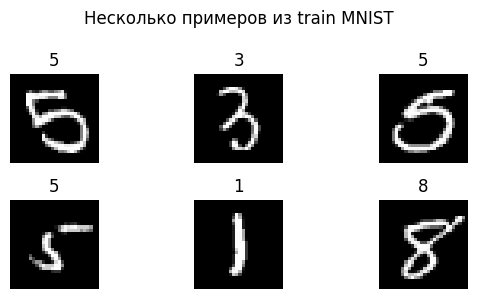

In [17]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» — это просто ваши наблюдения.

In [18]:
data_impression = """В целом цифры выглядят достаточно чёткими и в большинстве случаев их легко различить. Но есть и такие изображения, где цифры написаны неаккуратно или странно, поэтому может быть сложно отличить даже мне.
Например, некоторые 4 похожи на 9, а 7 может напоминать 1 или 2. Поэтому можно ожидать, что модель тоже будет иногда путать такие похожие случаи."""
print(data_impression)

В целом цифры выглядят достаточно чёткими и в большинстве случаев их легко различить. Но есть и такие изображения, где цифры написаны неаккуратно или странно, поэтому может быть сложно отличить даже мне.
Например, некоторые 4 похожи на 9, а 7 может напоминать 1 или 2. Поэтому можно ожидать, что модель тоже будет иногда путать такие похожие случаи.


## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** — без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** — тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** — тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [49]:
class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            # TODO: размеры слоёв (256, 128) выбраны произвольно.
            # Подберите свои значения и обоснуйте в отчёте:
            # достаточно ли этого, чтобы модель вообще могла переобучиться?
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: Dropout стоит ПОСЛЕ активации, это стандартная практика.
        # Попробуйте поставить его ДО активации и опишите, изменилось ли что-то.
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, что физически происходит здесь во время train?
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, почему здесь тот же p, а не другой?
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: BatchNorm1d стоит ДО активации — это один из двух стандартных вариантов.
        # Попробуйте переставить его после ReLU. Есть ли разница в сходимости?
        # TODO: объясните в отчёте: что именно нормализует BatchNorm1d(256)?
        # Что такое «батч» в данном контексте, строки или столбцы матрицы?
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(BaseMLP())
print(DropoutMLP())
print(BatchNormMLP())

BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)
BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): B

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` — один проход по train;
- `evaluate` — оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование — делайте это здесь и прокомментируйте в отчёте.


In [50]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [51]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.5,
                   num_epochs=8, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    # создаём модель нужного класса
    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model, history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` — BaseMLP, `weight_decay=0`.  
2. `Base / L2` — BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` — DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` — BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [23]:
# 1. Базовая модель без регуляризации
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / no_reg ===
Эпоха 1/8 | train_loss=0.2298, train_acc=0.9299, test_loss=0.1034, test_acc=0.9673
Эпоха 2/8 | train_loss=0.0887, train_acc=0.9722, test_loss=0.0998, test_acc=0.9685
Эпоха 3/8 | train_loss=0.0606, train_acc=0.9806, test_loss=0.0768, test_acc=0.9743
Эпоха 4/8 | train_loss=0.0418, train_acc=0.9861, test_loss=0.0692, test_acc=0.9800
Эпоха 5/8 | train_loss=0.0332, train_acc=0.9891, test_loss=0.0767, test_acc=0.9796
Эпоха 6/8 | train_loss=0.0265, train_acc=0.9914, test_loss=0.0891, test_acc=0.9770
Эпоха 7/8 | train_loss=0.0249, train_acc=0.9915, test_loss=0.0791, test_acc=0.9801
Эпоха 8/8 | train_loss=0.0231, train_acc=0.9927, test_loss=0.0885, test_acc=0.9770


In [47]:
# 2. Базовая модель с L2 (weight decay)
# TODO: weight_decay=1e-4 — почему именно это значение?
# Попробуйте 1e-2 и 1e-6. Запишите test_acc для каждого случая и опишите, где слишком много L2.
l2_model, l2_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / L2 (wd=1e-4)",
    weight_decay=1e-2,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / L2 (wd=1e-4) ===
Эпоха 1/8 | train_loss=0.2946, train_acc=0.9159, test_loss=0.1882, test_acc=0.9450
Эпоха 2/8 | train_loss=0.1923, train_acc=0.9448, test_loss=0.1733, test_acc=0.9521
Эпоха 3/8 | train_loss=0.1727, train_acc=0.9515, test_loss=0.1480, test_acc=0.9601
Эпоха 4/8 | train_loss=0.1616, train_acc=0.9556, test_loss=0.1561, test_acc=0.9566
Эпоха 5/8 | train_loss=0.1562, train_acc=0.9568, test_loss=0.1500, test_acc=0.9576
Эпоха 6/8 | train_loss=0.1500, train_acc=0.9592, test_loss=0.1427, test_acc=0.9607
Эпоха 7/8 | train_loss=0.1490, train_acc=0.9596, test_loss=0.1411, test_acc=0.9617
Эпоха 8/8 | train_loss=0.1453, train_acc=0.9606, test_loss=0.1350, test_acc=0.9652


In [53]:
# 3. Модель с Dropout
# TODO: dropout_p=0.5 — агрессивное значение. Попробуйте p=0.2 и p=0.7.
# При каком p модель обучается слишком медленно, а при каком почти не регуляризует?
drop_model, drop_hist = run_experiment(
    model_class=DropoutMLP,
    config_name="Dropout p=0.2",
    dropout_p=0.2,
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Dropout p=0.2 ===
Эпоха 1/8 | train_loss=0.2589, train_acc=0.9213, test_loss=0.1118, test_acc=0.9652
Эпоха 2/8 | train_loss=0.1102, train_acc=0.9658, test_loss=0.0873, test_acc=0.9731
Эпоха 3/8 | train_loss=0.0811, train_acc=0.9739, test_loss=0.0690, test_acc=0.9768
Эпоха 4/8 | train_loss=0.0642, train_acc=0.9797, test_loss=0.0689, test_acc=0.9785
Эпоха 5/8 | train_loss=0.0547, train_acc=0.9824, test_loss=0.0671, test_acc=0.9798
Эпоха 6/8 | train_loss=0.0488, train_acc=0.9842, test_loss=0.0700, test_acc=0.9795
Эпоха 7/8 | train_loss=0.0431, train_acc=0.9866, test_loss=0.0623, test_acc=0.9828
Эпоха 8/8 | train_loss=0.0389, train_acc=0.9871, test_loss=0.0640, test_acc=0.9812


In [39]:
# 4. Модель с BatchNorm
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: BatchNorm ===
Эпоха 1/8 | train_loss=0.1853, train_acc=0.9465, test_loss=0.0897, test_acc=0.9722
Эпоха 2/8 | train_loss=0.0729, train_acc=0.9773, test_loss=0.0711, test_acc=0.9773
Эпоха 3/8 | train_loss=0.0462, train_acc=0.9858, test_loss=0.0669, test_acc=0.9788
Эпоха 4/8 | train_loss=0.0331, train_acc=0.9896, test_loss=0.0579, test_acc=0.9835
Эпоха 5/8 | train_loss=0.0251, train_acc=0.9918, test_loss=0.0681, test_acc=0.9814
Эпоха 6/8 | train_loss=0.0210, train_acc=0.9931, test_loss=0.0635, test_acc=0.9811
Эпоха 7/8 | train_loss=0.0173, train_acc=0.9942, test_loss=0.0635, test_acc=0.9812
Эпоха 8/8 | train_loss=0.0152, train_acc=0.9950, test_loss=0.0627, test_acc=0.9826


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов:
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


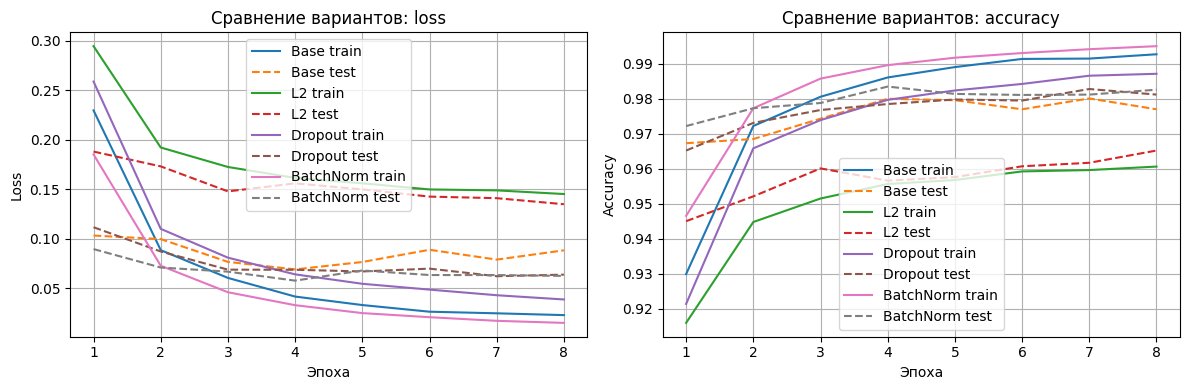

In [54]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[base_hist, l2_hist, drop_hist, bn_hist],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение вариантов: "
)

## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) — это тоже часть обучения.


In [55]:
analysis_comment = """Базовая модель обучается очень быстро, уже к 4–5 эпохе train accuracy достигает 0.99, а test accuracy выходит на уровень около 0.98. При этом видно, что train продолжает расти (до 0.9927), а test начинает колебаться (около 0.977–0.980), что говорит о начале переобучения.
Добавление L2-регуляризации (1e-4) немного «сдерживает» модель. train accuracy становится ниже, а кривые выглядят более плавными. Однако явного улучшения test accuracy нет, она остаётся примерно на том же уровне (0.975–0.980). При слишком большом weight_decay (1e-2) модель уже обучается хуже: train accuracy ниже (0.96), и test accuracy падает до 0.965, то есть регуляризация становится слишком сильной.
Dropout: обучение идёт медленнее, train accuracy ниже (0.97), но test accuracy постепенно растёт и достигает 0.9825. При этом разрыв между train и test меньше,  что говорит о лучшем обобщении. Обучение не ломается, но становится более «шумным» и медленным.
BatchNorm заметно ускоряет обучение: модель быстрее выходит на высокую точность, а кривые становятся более гладкими. Test accuracy достигает 0.9826, что является одним из лучших результатов.
Если выбирать одну технику регуляризации, я бы выбрала BatchNorm, так как она ускоряет обучение и даёт высокий результат без явных недостатков. Dropout тоже показал себя хорошо, но он сильнее замедляет обучение."""
print(analysis_comment)

Базовая модель обучается очень быстро, уже к 4–5 эпохе train accuracy достигает 0.99, а test accuracy выходит на уровень около 0.98. При этом видно, что train продолжает расти (до 0.9927), а test начинает колебаться (около 0.977–0.980), что говорит о начале переобучения.
Добавление L2-регуляризации (1e-4) немного «сдерживает» модель. train accuracy становится ниже, а кривые выглядят более плавными. Однако явного улучшения test accuracy нет, она остаётся примерно на том же уровне (0.975–0.980). При слишком большом weight_decay (1e-2) модель уже обучается хуже: train accuracy ниже (0.96), и test accuracy падает до 0.965, то есть регуляризация становится слишком сильной.
Dropout: обучение идёт медленнее, train accuracy ниже (0.97), но test accuracy постепенно растёт и достигает 0.9825. При этом разрыв между train и test меньше,  что говорит о лучшем обобщении. Обучение не ломается, но становится более «шумным» и медленным.
BatchNorm заметно ускоряет обучение: модель быстрее выходит на выс

## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm — именно на примере **ваших** экспериментов, а не абстрактной теории.


In [56]:
final_summary = """В этой работе оптимальной конфигурацией для меня стала модель с архитектурой 512-256, learning rate = 1e-3, числом эпох около 8 и использованием BatchNorm или Dropout (p=0.5). Такая комбинация даёт высокую точность (0.982–0.983) и стабильное обучение без сильного переобучения.
Ожидания в целом подтвердились: регуляризация действительно помогает улучшить обобщение,но оказалось, что слишком сильная L2 (например, 1e-2) заметно ухудшает качество. Также я увидела, что Dropout замедляет обучение, а BatchNorm, наоборот, ускоряет его.
По результатам экспериментов я бы объяснила так: L2 стоит использовать как мягкую регуляризацию ;Dropout, когда есть риск переобучения, но нужно быть осторожным с параметром p; BatchNorm, когда хочется ускорить обучение и сделать его более стабильным.
В дальнейшем я бы начинала с BatchNorm и базовых настроек, а затем при необходимости добавляла Dropout или L2."""
print(final_summary)

В этой работе оптимальной конфигурацией для меня стала модель с архитектурой 512-256, learning rate = 1e-3, числом эпох около 8 и использованием BatchNorm или Dropout (p=0.5). Такая комбинация даёт высокую точность (0.982–0.983) и стабильное обучение без сильного переобучения.
Ожидания в целом подтвердились: регуляризация действительно помогает улучшить обобщение,но оказалось, что слишком сильная L2 (например, 1e-2) заметно ухудшает качество. Также я увидела, что Dropout замедляет обучение, а BatchNorm, наоборот, ускоряет его.
По результатам экспериментов я бы объяснила так: L2 стоит использовать как мягкую регуляризацию ;Dropout, когда есть риск переобучения, но нужно быть осторожным с параметром p; BatchNorm, когда хочется ускорить обучение и сделать его более стабильным.
В дальнейшем я бы начинала с BatchNorm и базовых настроек, а затем при необходимости добавляла Dropout или L2.
